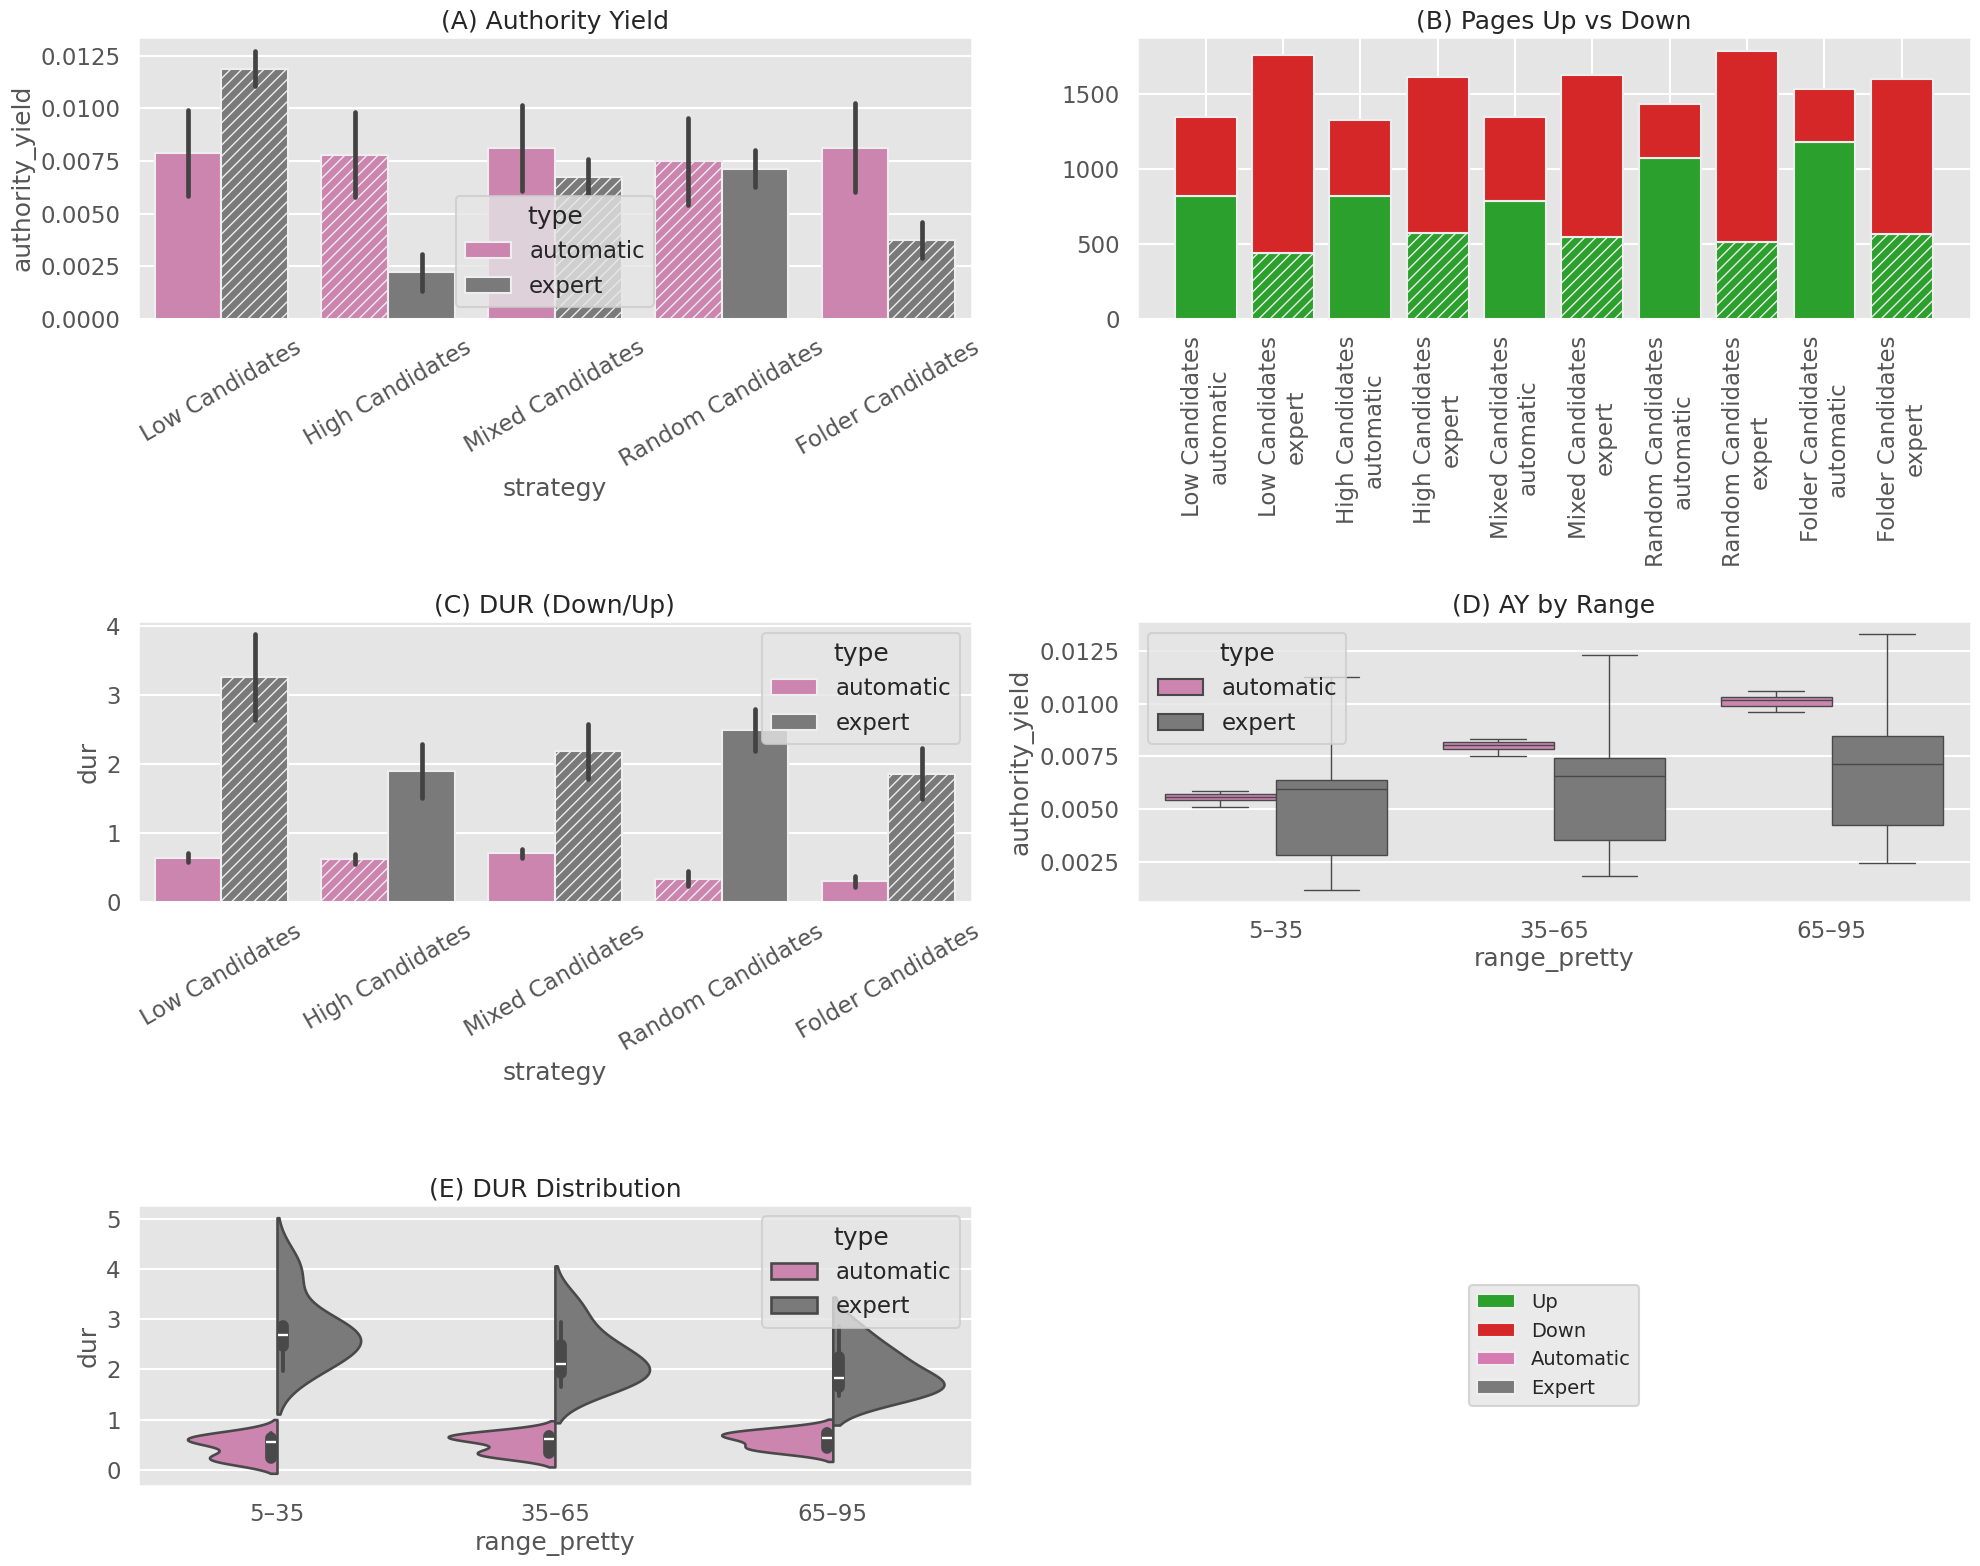

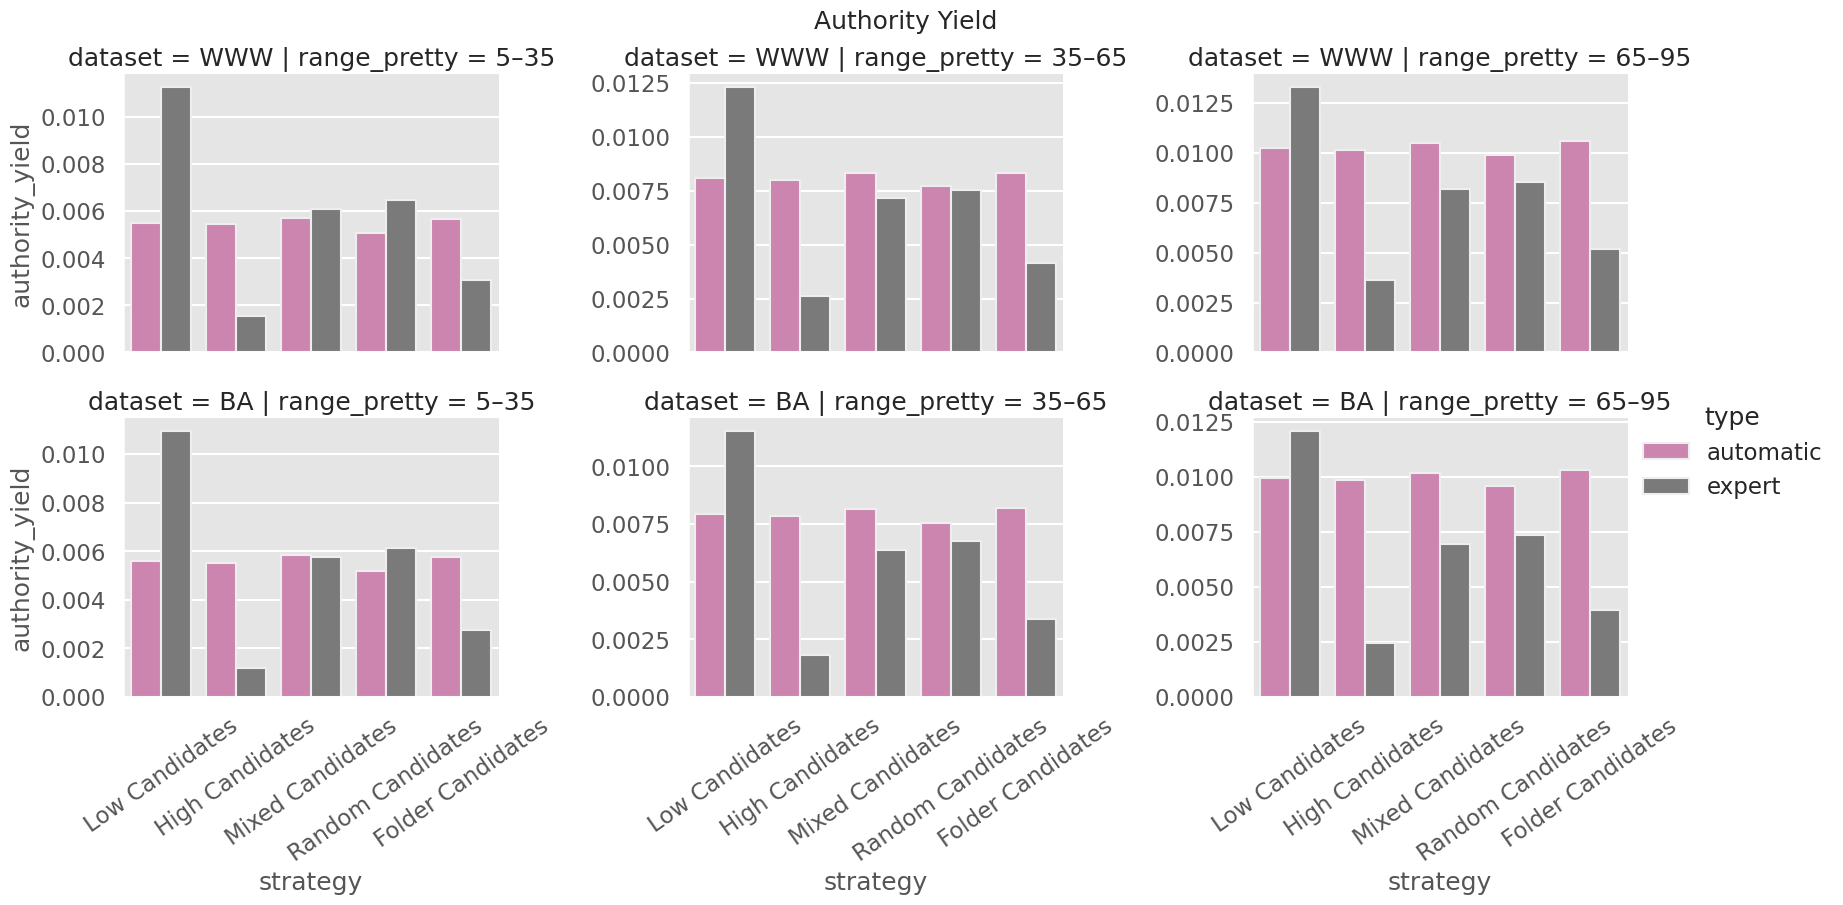

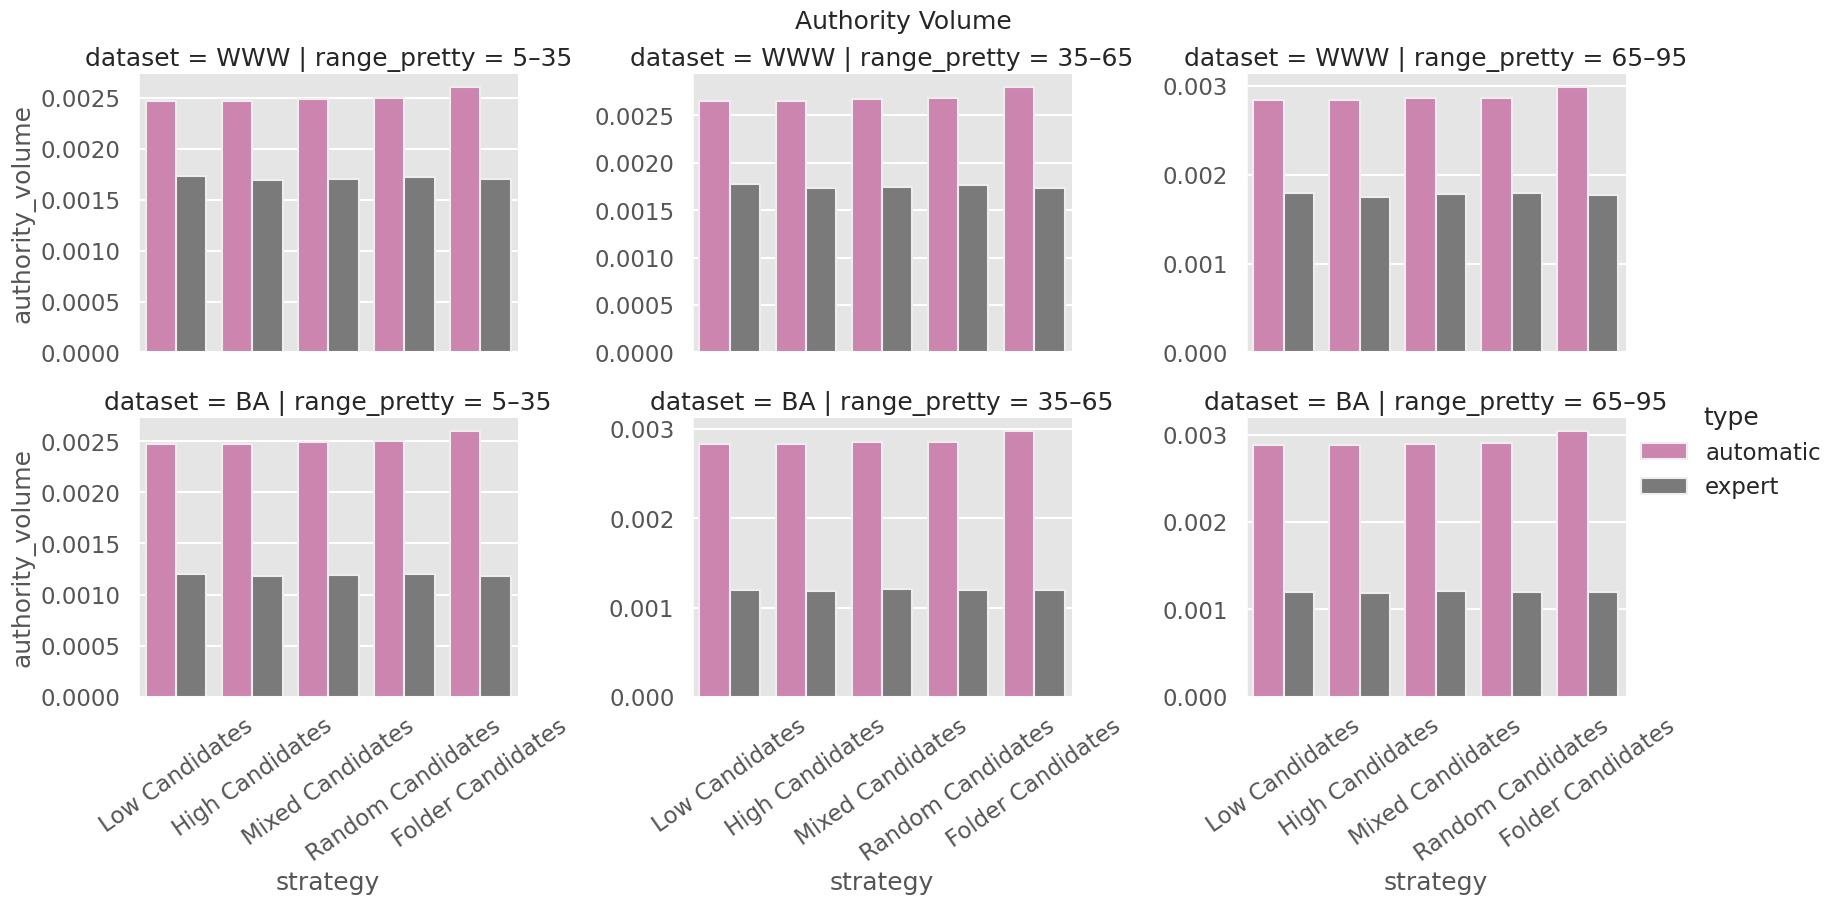

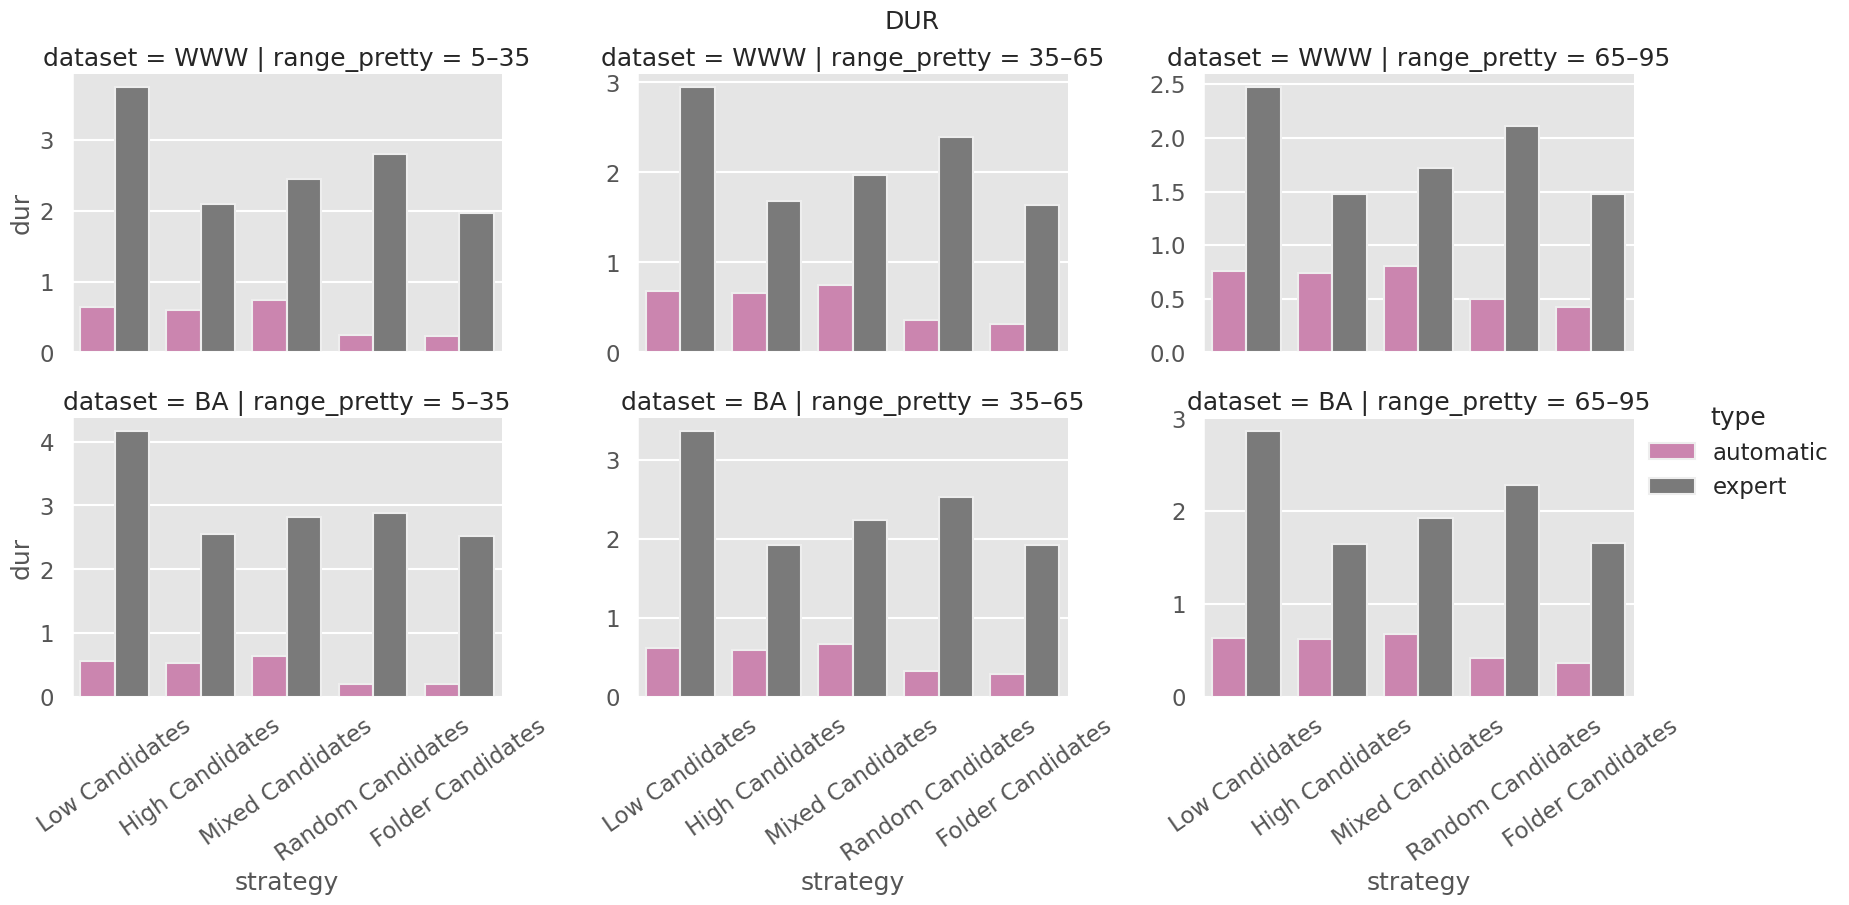

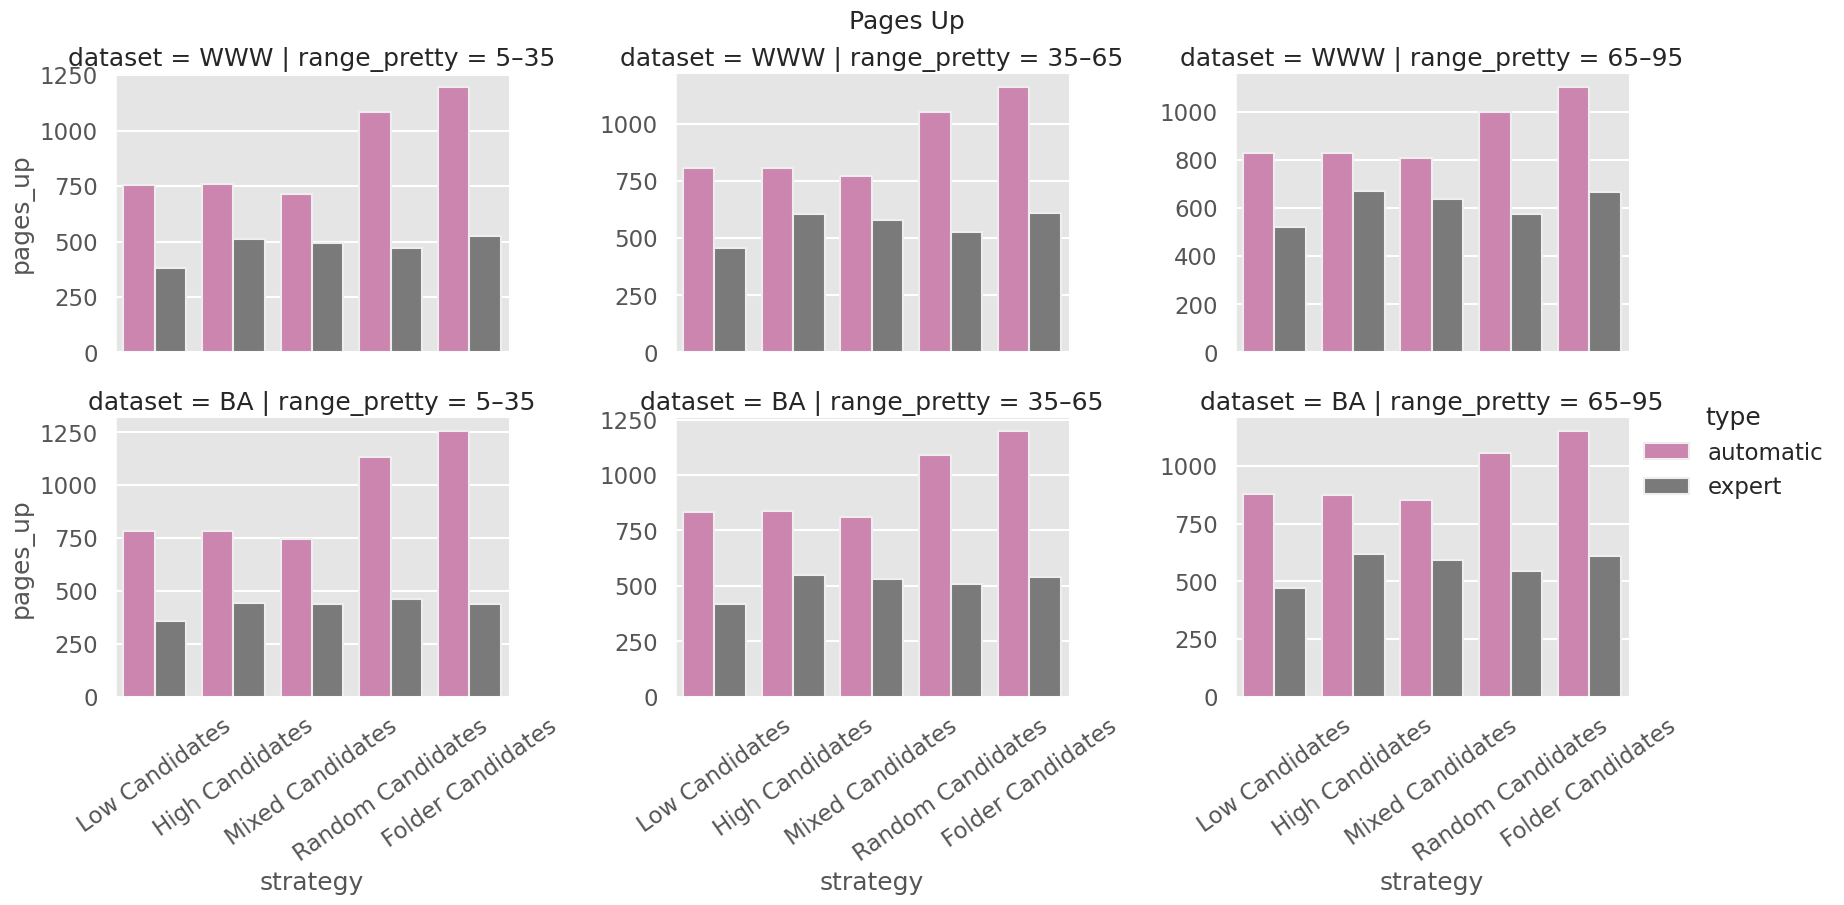

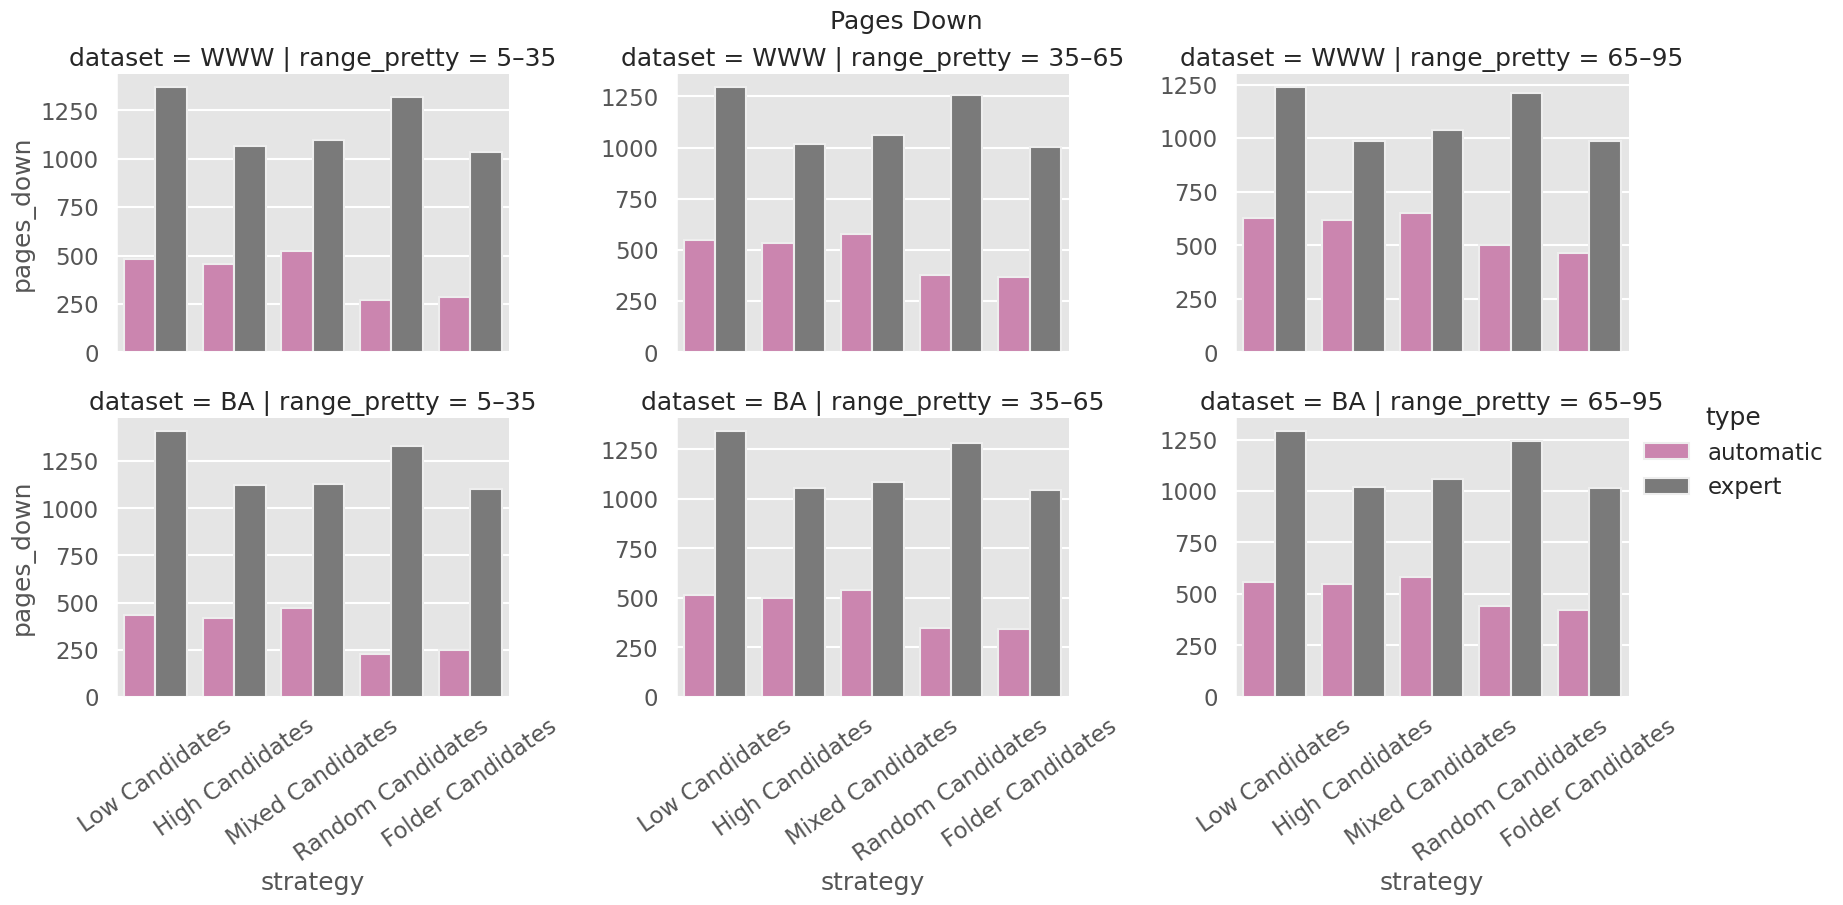

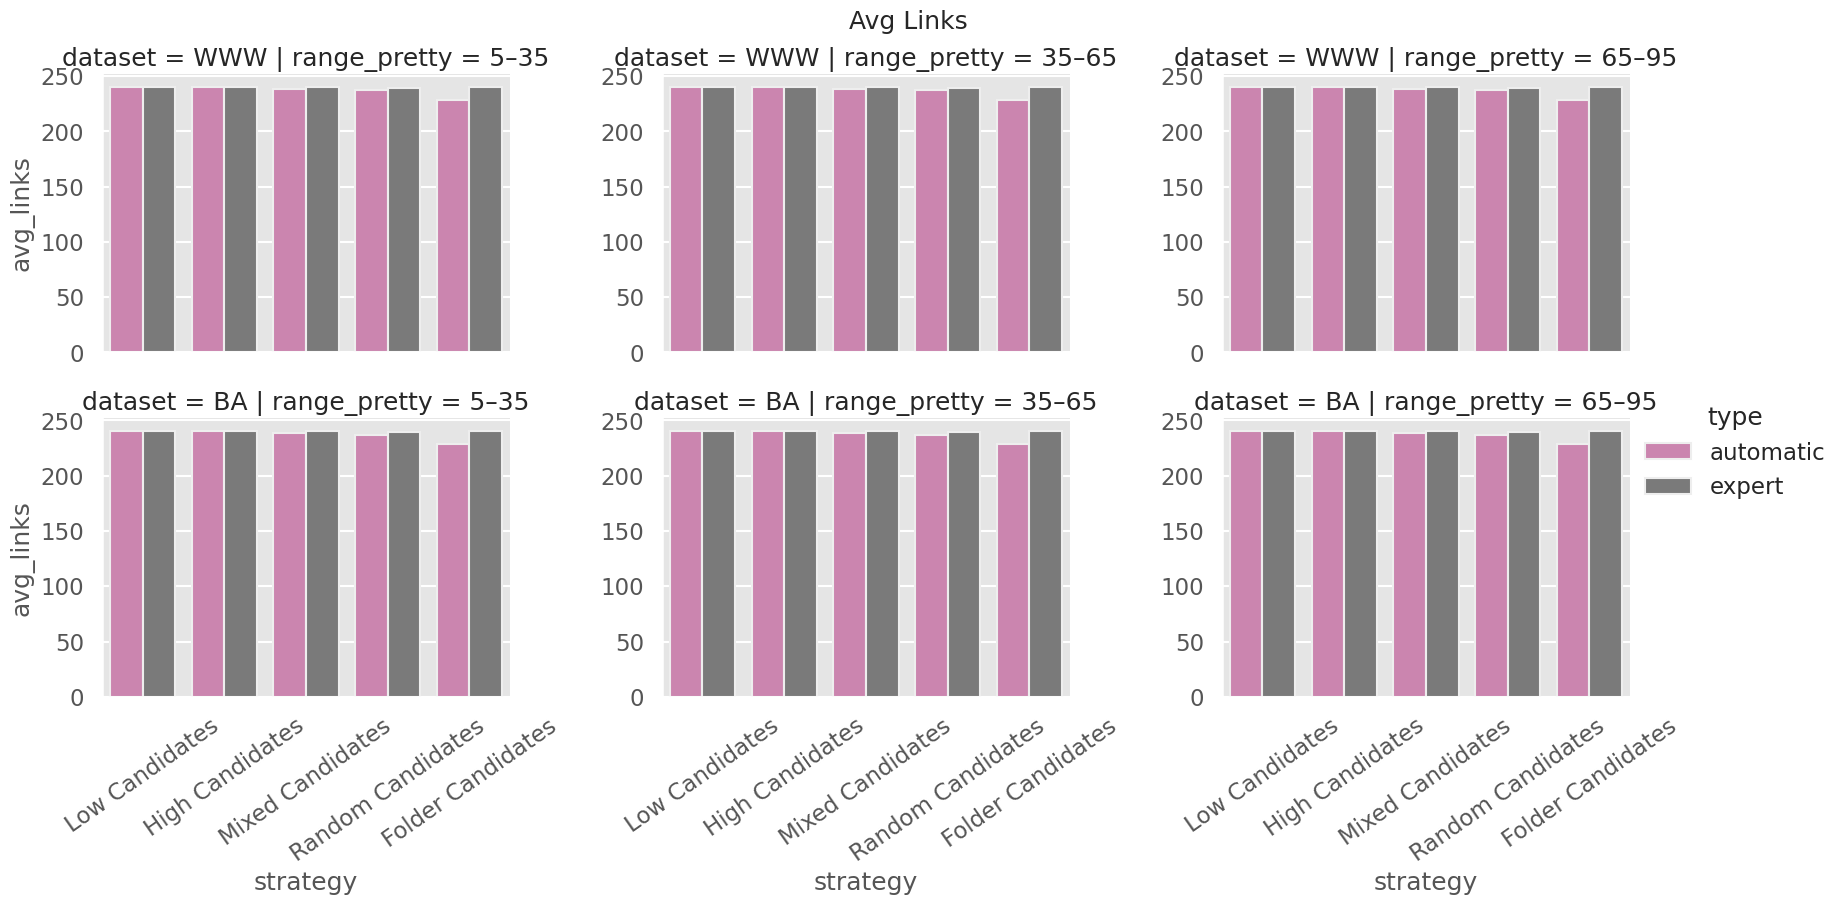

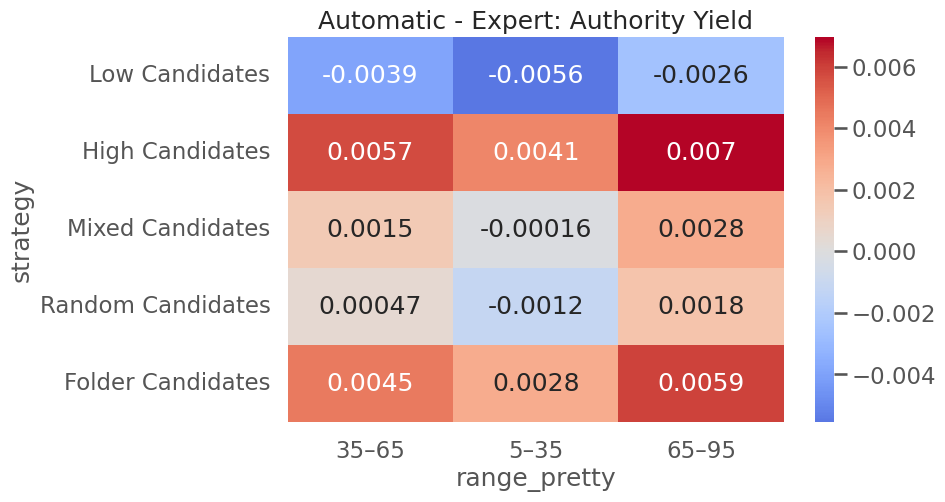

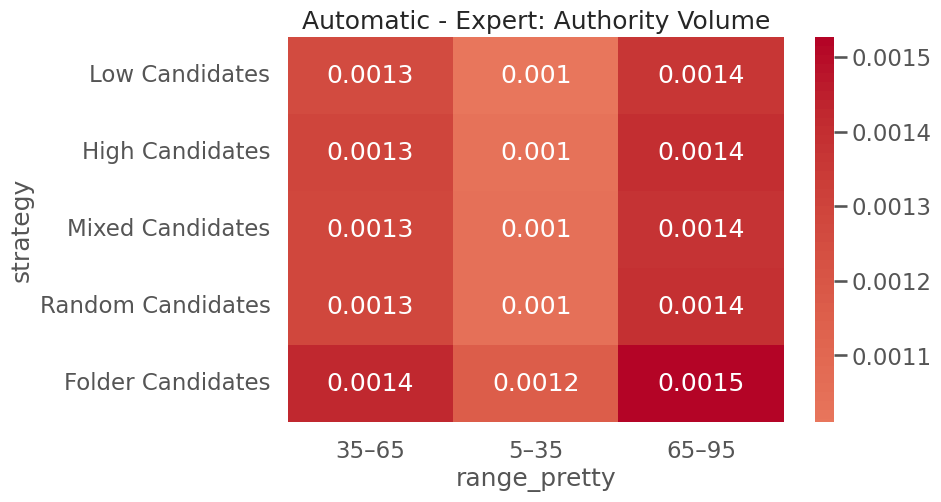

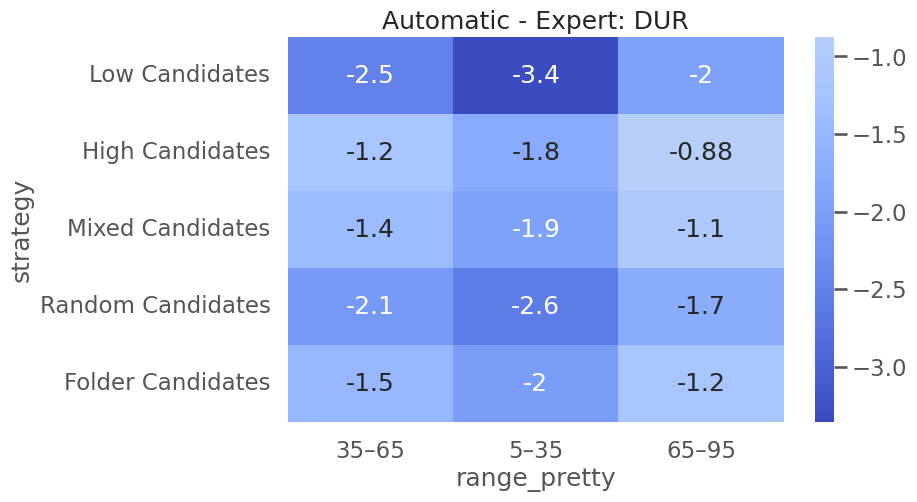

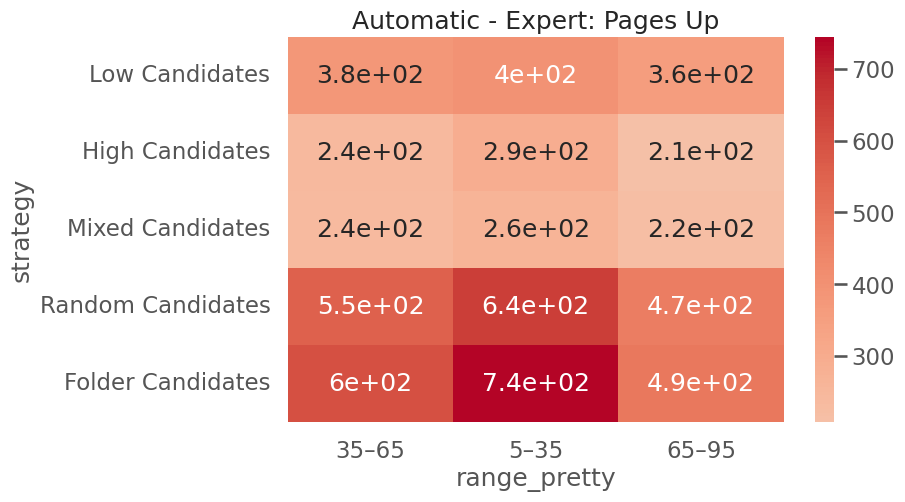

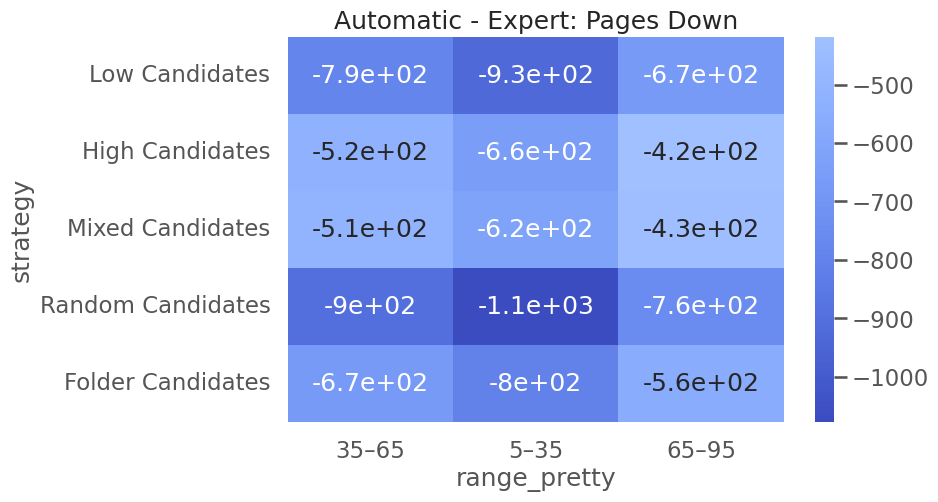

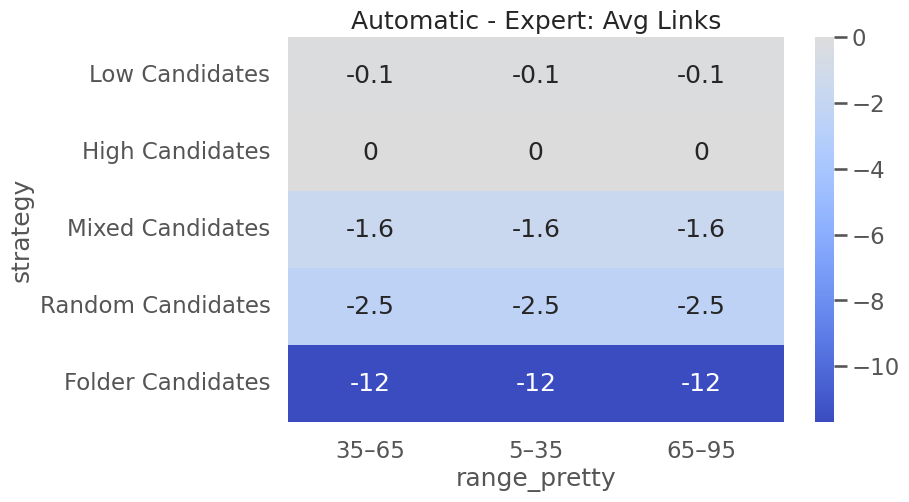

In [3]:
# =========================================
# WEBKNOGRAPH VISUALIZATION ONLY
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# -----------------------------------------
# STYLE
# -----------------------------------------
plt.style.use("ggplot")
sns.set_context("talk")

COLORS = {
    "automatic": "#d67ab1",
    "expert": "#7a7a7a",
    "up": "#2ca02c",
    "down": "#d62728",
}

# -----------------------------------------
# LOAD FILES (ADJUST PATH IF NEEDED)
# -----------------------------------------
files = {
    ("automatic", "WWW"): "OVERALL_AVERAGES_TRACKER_AUTOMATIC_WWW.csv",
    ("automatic", "BA"):  "OVERALL_AVERAGES_TRACKER_AUTOMATIC_BA.csv",
    ("expert", "WWW"):    "OVERALL_AVERAGES_TRACKER_EXPERT_WWW.csv",
    ("expert", "BA"):     "OVERALL_AVERAGES_TRACKER_EXPERT_BA.csv",
}

dfs = []
for (eval_type, dataset), path in files.items():
    df = pd.read_csv(path)
    df["type"] = eval_type
    df["dataset"] = dataset
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# -----------------------------------------
# CLEAN + RENAME
# -----------------------------------------
df.columns = [c.strip() for c in df.columns]

df = df.rename(columns={
    "Strategy": "strategy",
    "Range": "range",
    "Overall_Avg_AY": "authority_yield",
    "Overall_Avg_AV": "authority_volume",
    "Overall_Avg_DUR": "dur",
    "Overall_Avg_Pages_Up": "pages_up",
    "Overall_Avg_Pages_Down": "pages_down",
    "Avg_Links_Inserted_k": "avg_links"
})

# -----------------------------------------
# NORMALIZE STRATEGY
# -----------------------------------------
def normalize(s):
    s = str(s).lower()
    mapping = {
        "random_batches": "Random Candidates",
        "high_batches": "High Candidates",
        "folder_batches": "Folder Candidates",
        "baseline_batches": "Baseline",
        "mixed_batches": "Mixed Candidates",
        "low_batches": "Low Candidates",
    }
    return mapping.get(s, s.title())

df["strategy"] = df["strategy"].apply(normalize)

strategy_order = [
    "Low Candidates",
    "High Candidates",
    "Mixed Candidates",
    "Random Candidates",
    "Baseline",
    "Folder Candidates",
]

strategy_order = [s for s in strategy_order if s in df["strategy"].unique()]

range_map = {
    "Range_5-35": "5–35",
    "Range_35-65": "35–65",
    "Range_65-95": "65–95"
}
df["range_pretty"] = df["range"].map(range_map)

# -----------------------------------------
# DERIVED
# -----------------------------------------
df["dur_calc"] = df["pages_down"] / df["pages_up"]

# =========================================
# MAIN FIGURE (SKELETON)
# =========================================
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()

# -----------------------------------------
# (A) AUTHORITY YIELD
# -----------------------------------------
sns.barplot(
    data=df,
    x="strategy",
    y="authority_yield",
    hue="type",
    order=strategy_order,
    palette=[COLORS["automatic"], COLORS["expert"]],
    errorbar="sd",
    ax=axes[0]
)
axes[0].set_title("(A) Authority Yield")
axes[0].tick_params(axis="x", rotation=30)

# hatch expert
for i, p in enumerate(axes[0].patches):
    if i % 2 == 1:
        p.set_hatch("///")

# -----------------------------------------
# (B) UP vs DOWN STACKED
# -----------------------------------------
agg = df.groupby(["strategy", "type"])[["pages_up", "pages_down"]].mean().reset_index()

x = []
up = []
down = []

for s in strategy_order:
    for t in ["automatic", "expert"]:
        row = agg[(agg["strategy"] == s) & (agg["type"] == t)]
        if len(row) == 0:
            up.append(0)
            down.append(0)
        else:
            up.append(row["pages_up"].values[0])
            down.append(row["pages_down"].values[0])
        x.append(f"{s}\n{t}")

pos = np.arange(len(x))

axes[1].bar(pos, up, color=COLORS["up"])
axes[1].bar(pos, down, bottom=up, color=COLORS["down"])

# hatch expert
for i in range(len(pos)):
    if i % 2 == 1:
        axes[1].patches[i].set_hatch("///")

axes[1].set_xticks(pos)
axes[1].set_xticklabels(x, rotation=90)
axes[1].set_title("(B) Pages Up vs Down")

# -----------------------------------------
# (C) DUR
# -----------------------------------------
sns.barplot(
    data=df,
    x="strategy",
    y="dur",
    hue="type",
    order=strategy_order,
    palette=[COLORS["automatic"], COLORS["expert"]],
    errorbar="sd",
    ax=axes[2]
)
axes[2].set_title("(C) DUR (Down/Up)")
axes[2].tick_params(axis="x", rotation=30)

for i, p in enumerate(axes[2].patches):
    if i % 2 == 1:
        p.set_hatch("///")

# -----------------------------------------
# (D) AUTHORITY YIELD BY RANGE
# -----------------------------------------
sns.boxplot(
    data=df,
    x="range_pretty",
    y="authority_yield",
    hue="type",
    palette=[COLORS["automatic"], COLORS["expert"]],
    ax=axes[3]
)
axes[3].set_title("(D) AY by Range")

# -----------------------------------------
# (E) DUR DISTRIBUTION
# -----------------------------------------
sns.violinplot(
    data=df,
    x="range_pretty",
    y="dur",
    hue="type",
    split=True,
    palette=[COLORS["automatic"], COLORS["expert"]],
    ax=axes[4]
)
axes[4].set_title("(E) DUR Distribution")

# -----------------------------------------
# (F) LEGEND
# -----------------------------------------
axes[5].axis("off")

legend_elements = [
    Patch(facecolor=COLORS["up"], label="Up"),
    Patch(facecolor=COLORS["down"], label="Down"),
    Patch(facecolor=COLORS["automatic"], label="Automatic"),
    Patch(facecolor=COLORS["expert"], label="Expert"),
]

axes[5].legend(handles=legend_elements, loc="center", fontsize=14)

plt.tight_layout()
plt.show()

# =========================================
# METRIC-WISE FACET (KEY PART)
# =========================================
metrics = [
    ("authority_yield", "Authority Yield"),
    ("authority_volume", "Authority Volume"),
    ("dur", "DUR"),
    ("pages_up", "Pages Up"),
    ("pages_down", "Pages Down"),
    ("avg_links", "Avg Links"),
]

for key, title in metrics:
    g = sns.catplot(
        data=df,
        kind="bar",
        x="strategy",
        y=key,
        hue="type",
        col="range_pretty",
        row="dataset",
        order=strategy_order,
        palette=[COLORS["automatic"], COLORS["expert"]],
        errorbar="sd",
        height=4,
        aspect=1.4,
        sharey=False
    )

    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=35)

    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(title, fontsize=18)

    plt.show()

# =========================================
# DIFFERENCE HEATMAP (AUTOMATIC - EXPERT)
# =========================================
for key, title in metrics:
    auto = df[df["type"] == "automatic"].pivot_table(
        index="strategy", columns="range_pretty", values=key
    )
    expert = df[df["type"] == "expert"].pivot_table(
        index="strategy", columns="range_pretty", values=key
    )

    diff = auto - expert
    diff = diff.reindex(strategy_order)

    plt.figure(figsize=(8, 5))
    sns.heatmap(diff, annot=True, cmap="coolwarm", center=0)
    plt.title(f"Automatic - Expert: {title}")
    plt.show()